# Cosmatic Chemical 
---

Group Name

Team members:
- Husna Alderazi
- Mariam Isa

## Introduction 
__Introduction to the topic__ 

    ...

---

## Problem Statement

This study aims to analyze the speed of reporting the hazardous chemical in cosmatic products and removal them from the market or refomilating the product under the California Safe Cosmetics Act and monitored by the California Department of Public Health.

## Objectives:
__Questions that will guide the analysis to solve the problem__

1. Which primary product categories contain the highest diversity of chemicals?
2. Which chemicals appear most frequently across cosmetic products?
3. Which companies/brands use the widest variety of chemicals?
4. How has the reporting of chemicals changed over time?
5. . How have the number of reported chemicals, removed chemicals, and discontinued products changed over the years?

    ...

---

## Exploratory Data Analysis (EDA):

### Data Dictionary 

| Field                  | Type      | Description                                                                                                                                                                                                                                                                      |
|------------------------|-----------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| _id                    | int       |                                                                                                                                                                                                                                                                                  |
| CDPHId                 | text      | The California Department of Public Health (CDPH) internal identification number for product. Note that the CDPHId may appear more than once if a product has more than one Color/Scent/Flavor, more than one Category, or more than one Chemical Name/CAS number reported.       |
| ProductName            | text      | Product name as entered by manufacturer, packer and/or distributor. The product name is entered as free-text into the reporting database and may contain misspellings or other errors.                                                                                            |
| CSFId                  | text      | CDPH internal identification number for a color/scent/flavor.                                                                                                                                                                                                                    |
| CSF                    | text      | Color, scent and/or flavor as entered by manufacturer, packer and/or distributor. Not all products have specific colors, scents or flavors.                                                                                                                                       |
| CompanyId              | text      | CDPH internal identification number for company.                                                                                                                                                                                                                                 |
| CompanyName            | text      | Company name as entered by manufacturer, packer and/or distributor. May contain misspellings or other errors.                                                                                                                                                                    |
| BrandName              | text      | Brand name as entered by manufacturer, packer and/or distributor. May contain misspellings or other errors.                                                                                                                                                                      |
| PrimaryCategoryId      | text      | CDPH internal identification number for category.                                                                                                                                                                                                                                |
| PrimaryCategory        | text      | Type of product (13 primary categories: Baby Products, Bath Products, Fragrances, Hair Care Products, Hair Coloring Products, Makeup Products, Nail Products, Oral Hygiene Products, Personal Care Products, Shaving Products, Skin Care Products, Sun-Related Products, Tattoos).|
| SubCategoryId          | text      | CDPH internal identification number for subcategory.                                                                                                                                                                                                                             |
| SubCategory            | text      | Type of product within one of the 13 primary categories.                                                                                                                                                                                                                         |
| CasId                  | text      | CDPH internal identification number for chemical.                                                                                                                                                                                                                                |
| CasNumber              | text      | Chemical identification number (Chemical Abstracts Service registry number). Note that different forms of a chemical may have different CAS numbers.                                                                                                                              |
| ChemicalId             | text      | CDPH internal identification number for this chemical's record specific to this product.                                                                                                                                                                                         |
| ChemicalName           | text      | Name of chemical substance in cosmetic product. The California Safe Cosmetics Act requires companies to report products containing ingredients known or suspected to cause cancer or developmental or reproductive harm.                                                           |
| InitialDateReported    | timestamp | Date the product profile was created by manufacturer, packer and/or distributor; the date the product was first reported to CDPH.                                                                                                                                                |
| MostRecentDateReported | timestamp | Date the product profile was last modified by manufacturer, packer and/or distributor. Defaults to InitialDateReported value initially.                                                                                                                                           |
| DiscontinuedDate       | timestamp | If applicable, date the product was discontinued.                                                                                                                                                                                                                                |
| ChemicalCreatedAt      | timestamp | The date that this chemical was first reported to CDPH for this product.                                                                                                                                                                                                         |
| ChemicalUpdatedAt      | timestamp | Date this chemical report was last modified by manufacturer, packer and/or distributor. Defaults to ChemicalCreatedAt value initially.                                                                                                                                           |
| ChemicalDateRemoved    | timestamp | If applicable, date the chemical was removed from the product (i.e., reformulation).                                                                                                                                                                                             |
| ChemicalCount          | numeric   | Total number of current chemicals reported for this product. Does not include removed chemicals. This is a calculated field based on current reporting.                                                                                                                           |

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [253]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [254]:
data = pd.read_csv('cosmetic-chemicals.csv')

In [255]:
data.sample(5)

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
14281,3252,LE ROUGE / LIPSTICK,6586.0,130,22,CLARINS S.A.,CLARINS PARIS,44,Makeup Products (non-permanent),53,...,13463-67-7,5794,Titanium dioxide,10/12/2009,12/30/2010,NaN,10/12/2009,10/12/2009,NaN,1
26133,7926,Fashion Fair Fast Finish Foundation Stick - Ta...,12292.0,Fashion Fair Fast Finish Foundation Stick - Fa...,356,"Fashion Fair, LLC",Fashion Fair,44,Makeup Products (non-permanent),50,...,13463-67-7,12356,Titanium dioxide,12/07/2009,12/30/2010,NaN,12/07/2009,12/07/2009,NaN,1
80082,29010,Melted Matte Liquified Lipstick Miso Pretty,NaN,NaN,1103,Too Faced Cosmetics,Too Faced Cosmetics,44,Makeup Products (non-permanent),53,...,13463-67-7,47076,Titanium dioxide,09/23/2016,09/23/2016,NaN,09/23/2016,09/23/2016,NaN,1
84845,30726,JORDANA MADE TO LAST LIQUID EYESHADOW,47170.0,NaN,1159,MILANI COSMETICS,JORDANA,44,Makeup Products (non-permanent),48,...,13463-67-7,49901,Titanium dioxide,06/08/2017,06/08/2017,NaN,06/08/2017,06/08/2017,NaN,2
37594,13199,Lipstick,18932.0,Matte Brown Sugar,546,"Beauty 21 Cosmetics, Inc.",L.A. Girl,44,Makeup Products (non-permanent),53,...,13463-67-7,20597,Titanium dioxide,06/24/2010,12/30/2010,NaN,06/24/2010,06/24/2010,NaN,1


In [256]:
data.shape

(114635, 22)

In [257]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114635 entries, 0 to 114634
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CDPHId                  114635 non-null  int64  
 1   ProductName             114635 non-null  object 
 2   CSFId                   80662 non-null   float64
 3   CSF                     80237 non-null   object 
 4   CompanyId               114635 non-null  int64  
 5   CompanyName             114635 non-null  object 
 6   BrandName               114408 non-null  object 
 7   PrimaryCategoryId       114635 non-null  int64  
 8   PrimaryCategory         114635 non-null  object 
 9   SubCategoryId           114635 non-null  int64  
 10  SubCategory             114635 non-null  object 
 11  CasId                   114635 non-null  int64  
 12  CasNumber               108159 non-null  object 
 13  ChemicalId              114635 non-null  int64  
 14  ChemicalName        

In [258]:
data.describe()

,CDPHId,CSFId,CompanyId,PrimaryCategoryId,SubCategoryId,CasId,ChemicalId,ChemicalCount
count,114635.000000,80662.000000,114635.000000,114635.000000,114635.000000,114635.000000,114635.000000,114635.000000
mean,20304.858987,32608.658377,450.641532,51.076294,66.819252,674.094107,32837.556959,1.288359
std,12489.052554,19089.443910,409.533093,20.474341,35.822097,149.214101,20439.412299,0.636418
min,2.000000,1.000000,4.000000,1.000000,3.000000,2.000000,0.000000,0.000000
25%,8717.000000,15789.000000,86.000000,44.000000,48.000000,656.000000,13990.000000,1.000000
50%,20895.000000,32541.000000,297.000000,44.000000,52.000000,656.000000,32055.000000,1.000000
75%,31338.500000,48717.750000,798.000000,59.000000,65.000000,656.000000,51578.500000,1.000000
max,41524.000000,65009.000000,1391.000000,111.000000,172.000000,1242.000000,68074.000000,9.000000


In [259]:
data.columns

Index(['CDPHId', 'ProductName', 'CSFId', 'CSF', 'CompanyId', 'CompanyName',
       'BrandName', 'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId',
       'SubCategory', 'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName',
       'InitialDateReported', 'MostRecentDateReported', 'DiscontinuedDate',
       'ChemicalCreatedAt', 'ChemicalUpdatedAt', 'ChemicalDateRemoved',
       'ChemicalCount'],
      dtype='object')

### Data Handling: 
__Cleaning, transforming, and combining data__

In [261]:
#Convert the dates to timestamp type
data['InitialDateReported'] = pd.to_datetime(data['InitialDateReported'])
data['MostRecentDateReported'] = pd.to_datetime(data['MostRecentDateReported'])
data['ChemicalCreatedAt'] = pd.to_datetime(data['ChemicalCreatedAt'])
data['ChemicalUpdatedAt'] = pd.to_datetime(data['ChemicalUpdatedAt'])
data['DiscontinuedDate'] = pd.to_datetime(data['DiscontinuedDate'])
data['ChemicalDateRemoved'] = pd.to_datetime(data['ChemicalDateRemoved'])

In [262]:
# remove the deplicate rows where having the same 'CDPHId', 'ChemicalName', 'CasNumber' means the recored is duplicated 
data = data.drop_duplicates(subset=['CDPHId', 'ChemicalName', 'CasNumber']) 


### During the analysis and visilaizing of the data we discovered a problem with the dates in 'ChemicalDateRemoved' which is effecting the analysis 
### Below is the problem and how we adressed it 

In [368]:
data['ChemicalDateRemoved'].max()

Timestamp('2104-05-02 00:00:00')

In [365]:
data[data['ChemicalDateRemoved'] > '2021-01-01']

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Time_to_Chemical_Report,Time_to_discontoued,Time_to_Reformulation
500,334,Cleansing Foam,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Kandesn,90,Skin Care Products,93,...,2009-09-02,2013-09-16,NaT,2009-09-03,2013-12-05,2103-12-05,0,1 days,NaT,34425 days
544,364,Deep Moisture Lotion SPF-25,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Oi-Lin,106,Sun-Related Products,107,...,2009-09-02,2013-09-17,NaT,2009-09-03,2013-12-05,2103-12-05,0,1 days,NaT,34425 days
545,364,Deep Moisture Lotion SPF-25,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Oi-Lin,106,Sun-Related Products,107,...,2009-09-02,2013-09-17,NaT,2009-09-16,2013-12-05,2103-12-05,0,14 days,NaT,34412 days
548,365,Deep Moisture Lotion Tinted SPF-25,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Oi-Lin,106,Sun-Related Products,107,...,2009-09-02,2013-09-19,NaT,2009-09-16,2013-12-05,2103-12-05,0,14 days,NaT,34412 days
618,434,Hand & Body Lotion,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Kandesn,90,Skin Care Products,102,...,2009-09-03,2013-09-19,NaT,2009-09-03,2013-12-05,2103-12-05,0,0 days,NaT,34425 days
622,437,Rebuild Cream,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Oi-Lin,90,Skin Care Products,102,...,2009-09-03,2013-12-05,NaT,2009-09-03,2013-12-05,2103-12-05,0,0 days,NaT,34425 days
623,438,Balancing Splash,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Kandesn,90,Skin Care Products,103,...,2009-09-03,2013-09-19,NaT,2009-09-03,2013-12-05,2103-12-05,0,0 days,NaT,34425 days
2663,930,Night Emulsion,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Oi-Lin,90,Skin Care Products,102,...,2009-09-15,2013-12-05,NaT,2009-09-15,2013-12-05,2103-12-05,0,0 days,NaT,34413 days
2664,931,Natural Emulsion SPF 30,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Oi-Lin,106,Sun-Related Products,107,...,2009-09-15,2013-09-19,NaT,2009-09-15,2013-12-05,2103-12-05,0,0 days,NaT,34413 days
2665,931,Natural Emulsion SPF 30,NaN,NaN,71,"Sunrider Manufacturing, L.P.",Oi-Lin,106,Sun-Related Products,107,...,2009-09-15,2013-09-19,NaT,2009-09-15,2013-12-05,2103-12-05,0,0 days,NaT,34413 days


In [370]:
# 2103 → 2013
data.loc[data['ChemicalDateRemoved'].dt.year == 2103, 'ChemicalDateRemoved'] = data['ChemicalDateRemoved'] - pd.DateOffset(years=90)

# 2104 → 2014
data.loc[data['ChemicalDateRemoved'].dt.year == 2104, 'ChemicalDateRemoved'] = data['ChemicalDateRemoved'] - pd.DateOffset(years=90)

In [374]:
#now we check again if the problem is addresed 
data['ChemicalDateRemoved'].max()

Timestamp('2020-05-14 00:00:00')

In [380]:
data[data['ChemicalDateRemoved'] > '2021-01-01']
#now the problem is solved!!

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Time_to_Chemical_Report,Time_to_discontoued,Time_to_Reformulation


In [263]:
#Finding the duration of the following: 
data['Time_to_Chemical_Report'] = data['ChemicalCreatedAt'] - data['InitialDateReported'] #Time takes to detect the chemical 
data['Time_to_discontoued'] = data['DiscontinuedDate'] - data['InitialDateReported'] # The total time it hase been in the market 
data['Time_to_Reformulation'] = data['ChemicalDateRemoved'] - data['ChemicalCreatedAt'] #Time takes to reformation after the detection

data.head()


#chech the number of the reported without action, what is the trend overtime, is it related to a specific chemical 
#If there is spesific company that get along with 

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Time_to_Chemical_Report,Time_to_discontoued,Time_to_Reformulation
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,2009-06-17,2013-08-28,2011-02-01,2009-07-09,2009-07-09,NaT,1,22 days,594 days,NaT
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,2009-07-01,2009-07-01,NaT,2009-07-01,2009-07-01,NaT,2,0 days,NaT,NaT
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,2009-07-01,2009-07-01,NaT,2009-07-02,2009-07-02,NaT,2,1 days,NaT,NaT
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,2009-07-09,2013-08-28,NaT,2009-07-09,2009-07-09,NaT,1,0 days,NaT,NaT
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,2009-07-09,2013-08-28,2011-02-01,2009-07-09,2009-07-09,NaT,1,0 days,572 days,NaT


In [264]:
data['PrimaryCategory'].value_counts()

PrimaryCategory
Makeup Products (non-permanent)      20648
Nail Products                         8037
Skin Care Products                    5572
Bath Products                         2516
Hair Care Products (non-coloring)     1412
Sun-Related Products                   924
Hair Coloring Products                 816
Fragrances                             478
Personal Care Products                 447
Oral Hygiene Products                  397
Tattoos and Permanent Makeup           373
Shaving Products                       200
Baby Products                           46
Name: count, dtype: int64

In [265]:
data['ChemicalName'].value_counts()

ChemicalName
Titanium dioxide                                                                                       32024
Silica, crystalline (airborne particles of respirable size)                                             1358
Cocamide diethanolamine                                                                                  899
Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.      730
Carbon black                                                                                             718
                                                                                                       ...  
Benz[a]anthracene                                                                                          1
Benzo[a]pyrene                                                                                             1
2,2-Bis(bromomethyl)-1,3-propanediol                                                                       1
Spiron

### Analysis: 
__Answering the objectives through data analysis__



In [267]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41866 entries, 0 to 114634
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   CDPHId                   41866 non-null  int64          
 1   ProductName              41866 non-null  object         
 2   CSFId                    11388 non-null  float64        
 3   CSF                      11181 non-null  object         
 4   CompanyId                41866 non-null  int64          
 5   CompanyName              41866 non-null  object         
 6   BrandName                41785 non-null  object         
 7   PrimaryCategoryId        41866 non-null  int64          
 8   PrimaryCategory          41866 non-null  object         
 9   SubCategoryId            41866 non-null  int64          
 10  SubCategory              41866 non-null  object         
 11  CasId                    41866 non-null  int64          
 12  CasNumber             

<Axes: >

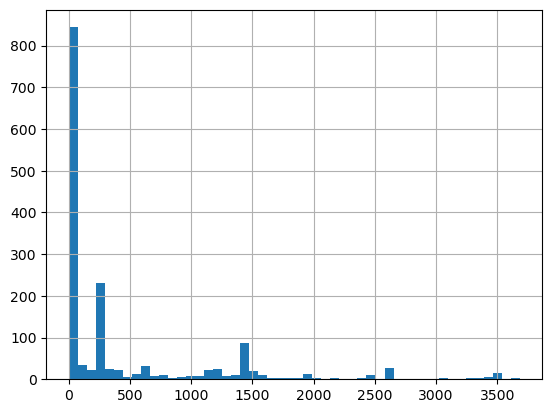

In [268]:
data['Time_to_Chemical_Report'] = pd.to_timedelta(data['Time_to_Chemical_Report'])

# Convert to number of days
days = data['Time_to_Chemical_Report'].dt.total_seconds() / (24 * 3600)
days = days[days > 0]

days.hist(bins=50)

In [269]:
data['Time_to_Chemical_Report'].value_counts()

Time_to_Chemical_Report
0 days       40298
1 days         152
252 days       113
13 days        109
3 days          78
             ...  
1100 days        1
215 days         1
2008 days        1
1660 days        1
153 days         1
Name: count, Length: 340, dtype: int64

In [270]:
data['Time_to_Chemical_Report'].describe()

count                          41866
mean      17 days 00:21:50.466727177
std      172 days 08:24:53.542575430
min                  0 days 00:00:00
25%                  0 days 00:00:00
50%                  0 days 00:00:00
75%                  0 days 00:00:00
max               3683 days 00:00:00
Name: Time_to_Chemical_Report, dtype: object

In [271]:
# Calculates the total number of chemical records in each PrimaryCategory to understand overall chemical distribution across categories
no_chem = data.groupby('PrimaryCategory')['ChemicalName'].count().reset_index(name='TotalChemicalCount').sort_values(by='TotalChemicalCount', ascending=False)
no_chem

,PrimaryCategory,TotalChemicalCount
5,Makeup Products (non-permanent),20648
6,Nail Products,8037
10,Skin Care Products,5572
1,Bath Products,2516
3,Hair Care Products (non-coloring),1412
11,Sun-Related Products,924
4,Hair Coloring Products,816
2,Fragrances,478
8,Personal Care Products,447
7,Oral Hygiene Products,397


## 1. Which primary product categories contain the highest diversity of chemicals?

In [273]:
# Calculates the number of unique chemicals in each PrimaryCategory and sorts categories by highest chemical diversity

no_unique_chem = data.groupby('PrimaryCategory')['ChemicalName'].nunique().reset_index(name='UniqueChemicalCount').sort_values(by='UniqueChemicalCount', ascending=False)
no_unique_chem

,PrimaryCategory,UniqueChemicalCount
10,Skin Care Products,82
3,Hair Care Products (non-coloring),68
5,Makeup Products (non-permanent),52
1,Bath Products,40
11,Sun-Related Products,35
6,Nail Products,32
8,Personal Care Products,30
4,Hair Coloring Products,23
2,Fragrances,22
9,Shaving Products,18


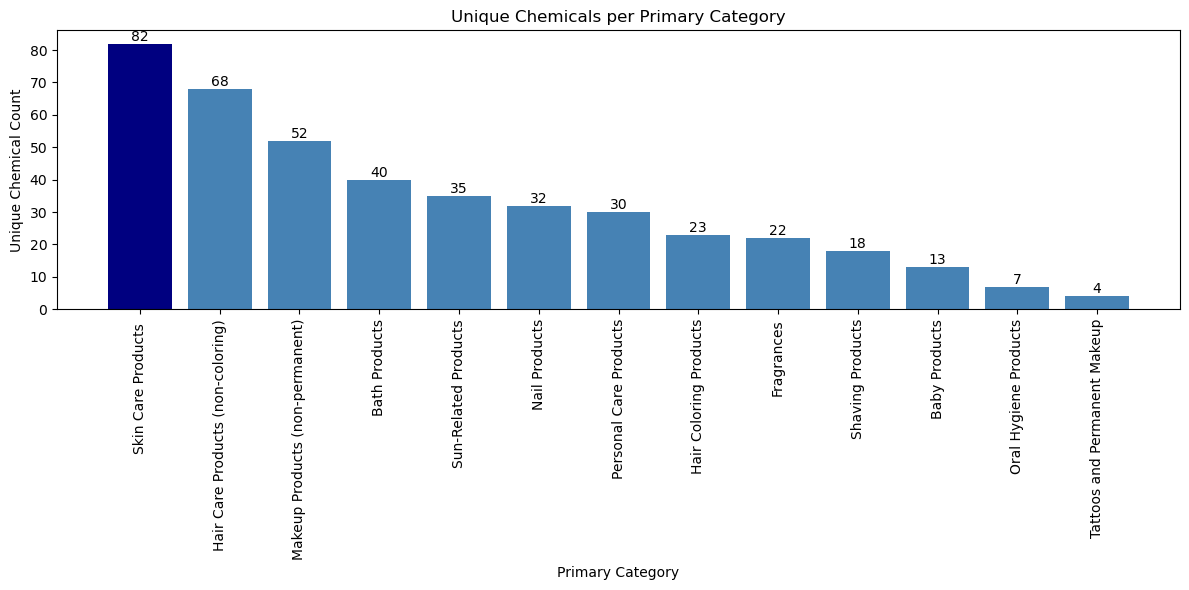

In [274]:
plt.figure(figsize=(12,6))

# Find the maximum value
max_value = no_unique_chem['UniqueChemicalCount'].max()

# Highlight max bar with darker color
colors = ['navy' if val == max_value else 'steelblue' 
          for val in no_unique_chem['UniqueChemicalCount']]

bars = plt.bar(no_unique_chem['PrimaryCategory'], 
               no_unique_chem['UniqueChemicalCount'], 
               color=colors)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.xticks(rotation=90)
plt.xlabel('Primary Category')
plt.ylabel('Unique Chemical Count')
plt.title('Unique Chemicals per Primary Category')
plt.tight_layout()
plt.show()

## 2. Which chemicals appear most frequently across cosmetic products?

In [276]:
top_chemicals = data['ChemicalName'].value_counts().head(10)
top_chemicals

ChemicalName
Titanium dioxide                                                                                       32024
Silica, crystalline (airborne particles of respirable size)                                             1358
Cocamide diethanolamine                                                                                  899
Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.      730
Carbon black                                                                                             718
Mica                                                                                                     678
Talc                                                                                                     587
Retinyl palmitate                                                                                        520
Butylated hydroxyanisole                                                                                 408
Vitami

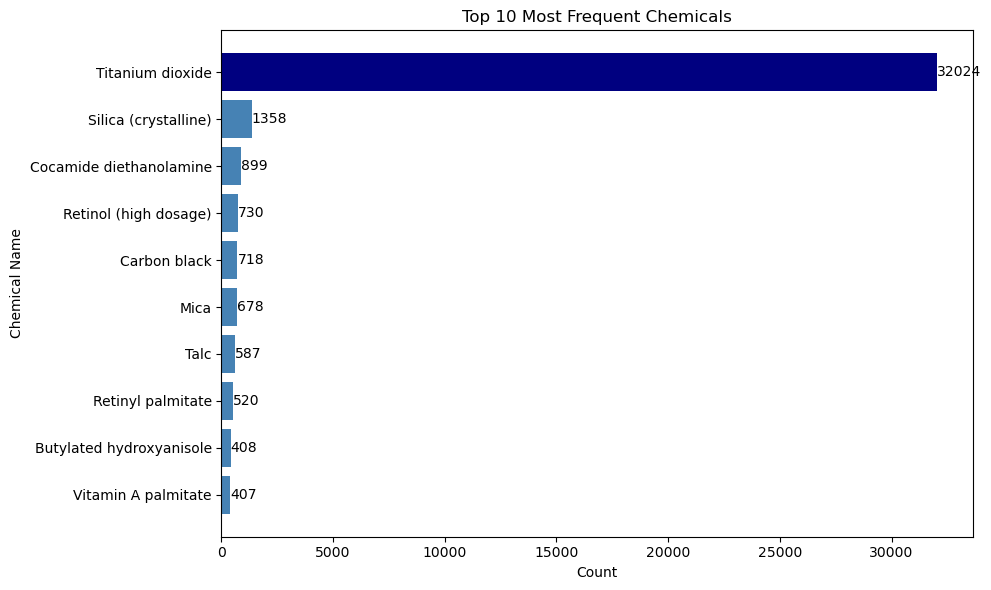

In [277]:
plt.figure(figsize=(10,6))

# Rename only specific long labels directly in the plot
labels = [
    "Silica (crystalline)" if x == "Silica, crystalline (airborne particles of respirable size)" 
    else "Retinol (high dosage)" if x == "Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents."
    else x
    for x in top_chemicals.index
]

# Get max value
max_value = top_chemicals.max()

# Colors
colors = ['navy' if val == max_value else 'steelblue' 
          for val in top_chemicals]

bars = plt.barh(labels, top_chemicals.values, color=colors)

# Add numbers
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', ha='left')

plt.xlabel('Count')
plt.ylabel('Chemical Name')
plt.title('Top 10 Most Frequent Chemicals')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [278]:
data.columns

Index(['CDPHId', 'ProductName', 'CSFId', 'CSF', 'CompanyId', 'CompanyName',
       'BrandName', 'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId',
       'SubCategory', 'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName',
       'InitialDateReported', 'MostRecentDateReported', 'DiscontinuedDate',
       'ChemicalCreatedAt', 'ChemicalUpdatedAt', 'ChemicalDateRemoved',
       'ChemicalCount', 'Time_to_Chemical_Report', 'Time_to_discontoued',
       'Time_to_Reformulation'],
      dtype='object')

## 3. Which companies/brands use the widest variety of chemicals?

In [280]:
comp_chem_unique = data.groupby('CompanyName')['ChemicalId'].nunique().sort_values(ascending=False).head(10)
comp_chem_unique

CompanyName
Nail Alliance - Entity                 2098
American International Industries      1988
Revlon Consumer Product Corporation    1471
AMOREPACIFIC US INC.                   1089
Buth-na-Bodhaige, Inc                  1073
L'Oreal USA                            1053
Hand & Nail Harmony, Inc                957
The Procter & Gamble Company            921
S+                                      879
Coty                                    872
Name: ChemicalId, dtype: int64

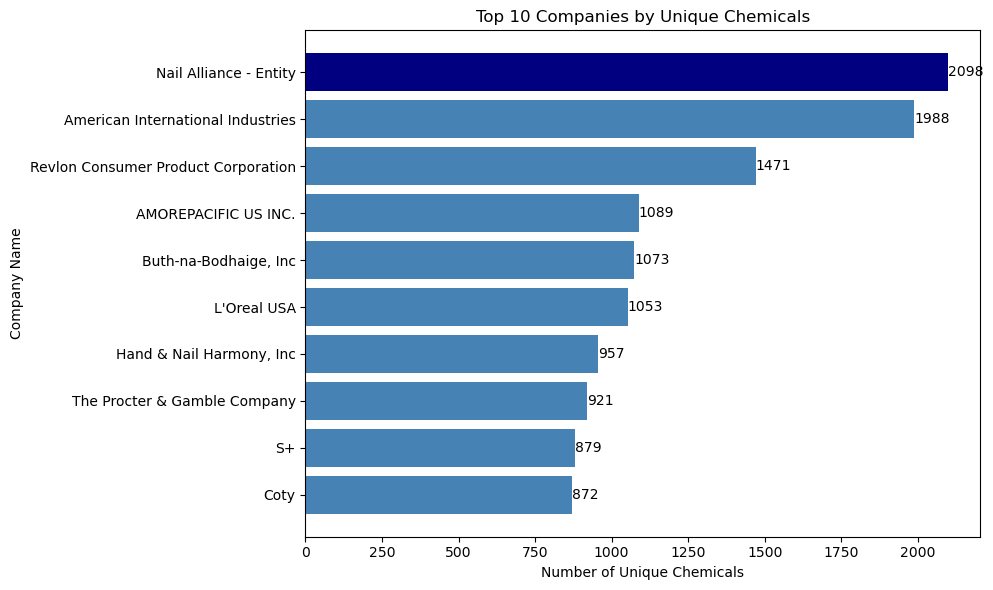

In [281]:
plt.figure(figsize=(10,6))

# Get max value
max_value = comp_chem_unique.max()

# Colors (highlight highest)
colors = ['navy' if val == max_value else 'steelblue' 
          for val in comp_chem_unique]

bars = plt.barh(comp_chem_unique.index, comp_chem_unique.values, color=colors)

# Add numbers at the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', ha='left')

plt.xlabel('Number of Unique Chemicals')
plt.ylabel('Company Name')
plt.title('Top 10 Companies by Unique Chemicals')

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

In [282]:
Brands_chem_unique = data.groupby('BrandName')['ChemicalId'].nunique().sort_values(ascending=False).head(10)
Brands_chem_unique 

BrandName
Revlon                      1069
The Body Shop               1036
Gelish                       994
Entity                       851
Anastasia Beverly Hills      772
Victoria's Secret Beauty     760
Artistic                     725
ZOEVA                        724
SEPHORA                      590
Bath & Body Works            502
Name: ChemicalId, dtype: int64

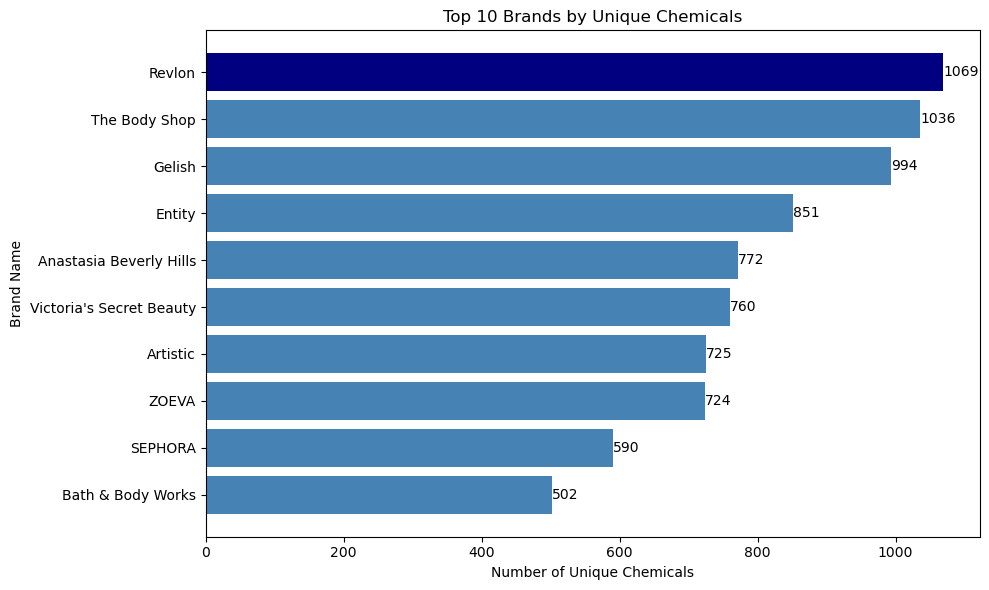

In [283]:
plt.figure(figsize=(10,6))

# Get max value
max_value = Brands_chem_unique.max()

# Colors (highlight highest)
colors = ['navy' if val == max_value else 'steelblue' 
          for val in Brands_chem_unique]

bars = plt.barh(Brands_chem_unique.index, Brands_chem_unique.values, color=colors)

# Add numbers at the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', ha='left')

plt.xlabel('Number of Unique Chemicals')
plt.ylabel('Brand Name')
plt.title('Top 10 Brands by Unique Chemicals')

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

## 4. How has the reporting of chemicals changed over the Years?

In [285]:
reported_chem_data = data[data['ChemicalCreatedAt'].notna()][['ChemicalCreatedAt']]
reported_chem_data

,ChemicalCreatedAt
0,2009-07-09
1,2009-07-01
2,2009-07-02
3,2009-07-09
4,2009-07-09
...,...
114622,2020-06-18
114623,2020-06-18
114626,2020-06-19
114630,2020-06-19


In [286]:
reported_chem_data['year'] = reported_chem_data['ChemicalCreatedAt'].dt.year
reported_chem_data

,ChemicalCreatedAt,year
0,2009-07-09,2009
1,2009-07-01,2009
2,2009-07-02,2009
3,2009-07-09,2009
4,2009-07-09,2009
...,...,...
114622,2020-06-18,2020
114623,2020-06-18,2020
114626,2020-06-19,2020
114630,2020-06-19,2020


In [287]:
chem_per_year = reported_chem_data.groupby('year').size()
chem_per_year

year
2009    9033
2010    5623
2011    1589
2012    1686
2013    2590
2014    3016
2015    3103
2016    2112
2017    3445
2018    3140
2019    5618
2020     911
dtype: int64

In [288]:
reported_chem_data['ChemicalCreatedAt'].max()

#we dont have the full data for the year 2020 thats why the number of reported cases is significantlly lower in 2020 so we will exclude it in the visual analysis 

Timestamp('2020-06-23 00:00:00')

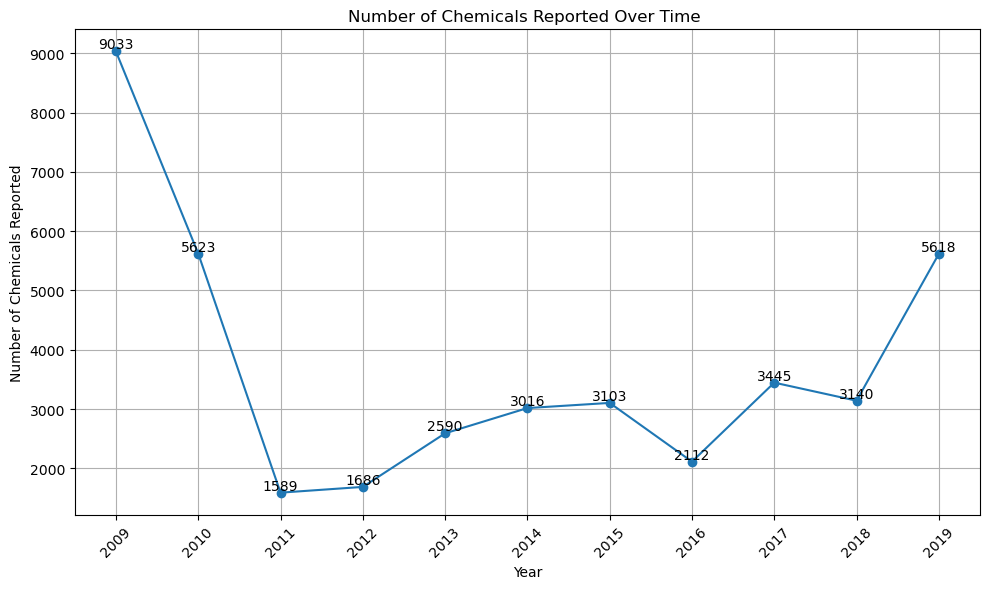

In [289]:
# Aggregate
chem_per_year = reported_chem_data.groupby('year').size().sort_index()

# Remove last year only for visualization
chem_per_year_plot = chem_per_year.iloc[:-1]

plt.figure(figsize=(10,6))

plt.plot(chem_per_year_plot.index, chem_per_year_plot.values, marker='o')

# Force all years to show
plt.xticks(chem_per_year_plot.index, rotation=45)

# Add labels
for x, y in zip(chem_per_year_plot.index, chem_per_year_plot.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Year')
plt.ylabel('Number of Chemicals Reported')
plt.title('Number of Chemicals Reported Over Time ')

plt.grid(True)
plt.tight_layout()
plt.show()

## 5. How have the number of reported chemicals, removed chemicals, and discontinued products changed over the years?

In [383]:
data_time= data[['ChemicalCreatedAt','ChemicalDateRemoved','DiscontinuedDate']].copy()
data_time

,ChemicalCreatedAt,ChemicalDateRemoved,DiscontinuedDate
0,2009-07-09,NaT,2011-02-01
1,2009-07-01,NaT,NaT
2,2009-07-02,NaT,NaT
3,2009-07-09,NaT,NaT
4,2009-07-09,NaT,2011-02-01
...,...,...,...
114622,2020-06-18,NaT,NaT
114623,2020-06-18,NaT,NaT
114626,2020-06-19,NaT,NaT
114630,2020-06-19,NaT,NaT


In [385]:
data_time['reported_year'] = data_time['ChemicalCreatedAt'].dt.year.astype('Int64')
data_time['removed_year'] = data_time['ChemicalDateRemoved'].dt.year.astype('Int64')
data_time['discountinued_year'] = data_time['DiscontinuedDate'].dt.year.astype('Int64')

In [387]:
data_time

,ChemicalCreatedAt,ChemicalDateRemoved,DiscontinuedDate,reported_year,removed_year,discountinued_year
0,2009-07-09,NaT,2011-02-01,2009,<NA>,2011
1,2009-07-01,NaT,NaT,2009,<NA>,<NA>
2,2009-07-02,NaT,NaT,2009,<NA>,<NA>
3,2009-07-09,NaT,NaT,2009,<NA>,<NA>
4,2009-07-09,NaT,2011-02-01,2009,<NA>,2011
...,...,...,...,...,...,...
114622,2020-06-18,NaT,NaT,2020,<NA>,<NA>
114623,2020-06-18,NaT,NaT,2020,<NA>,<NA>
114626,2020-06-19,NaT,NaT,2020,<NA>,<NA>
114630,2020-06-19,NaT,NaT,2020,<NA>,<NA>


In [389]:
reported = data_time['reported_year'].value_counts().sort_index()
removed = data_time['removed_year'].value_counts().sort_index()
discontinued = data_time['discountinued_year'].value_counts().sort_index()

In [391]:
trend_reporting = pd.DataFrame({'Reported' : reported ,
                               "Removed" : removed,
                               "Discontinued" : discontinued}).fillna(0)

In [393]:
trend_reporting

,Reported,Removed,Discontinued
2000,0,1,0
2001,0,0,2
2004,0,0,21
2005,0,0,6
2006,0,1,16
2007,0,0,117
2008,0,0,166
2009,9033,373,325
2010,5623,163,660
2011,1589,72,448


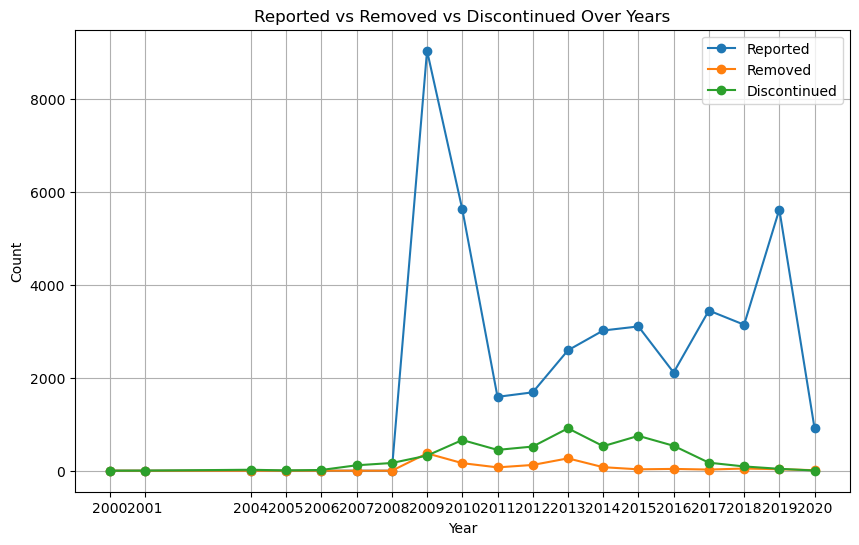

In [397]:
import matplotlib.pyplot as plt

trend_reporting.plot(figsize=(10,6), marker='o')

plt.title('Reported vs Removed vs Discontinued Over Years')
plt.xlabel('Year')
plt.ylabel('Count')


plt.xticks(trend_reporting.index)

plt.grid(True)
plt.show()

In [399]:
data[data['ChemicalDateRemoved'] < '2009-01-01']
#problem

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Time_to_Chemical_Report,Time_to_discontoued,Time_to_Reformulation
31512,9942,Whirlpool Shampoo & Body Wash,15465.0,D & C Green 8,421,"Central Solutions, Inc.",Central,18,Hair Care Products (non-coloring),25,...,2010-01-27,2013-09-05,2006-10-06,2010-01-27,2013-09-05,2006-10-06,0,0 days,-1209 days,-1209 days
91394,33433,Elixir Collection Scalp Therapy Elixir,NaN,NaN,908,"Rituals Cosmetics USA, Inc.",RITUALS,18,Hair Care Products (non-coloring),31,...,2018-07-03,2018-07-04,NaT,2018-07-03,2018-07-04,2000-01-01,1,0 days,NaT,-6758 days


In [401]:
data[data['DiscontinuedDate'] < '2009-01-01']
#problem

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount,Time_to_Chemical_Report,Time_to_discontoued,Time_to_Reformulation
1680,741,Zest Spring Burst Bar,NaN,NaN,86,The Procter & Gamble Company,Zest,6,Bath Products,159,...,2009-09-11,2017-05-11,2008-08-01,2009-09-11,2009-09-11,NaT,1,0 days,-406 days,NaT
4528,1318,Boy Toys,NaN,NaN,21,TIGI Linea Corp,Bed Head,18,Hair Care Products (non-coloring),26,...,2009-09-21,2011-10-20,2006-12-01,2009-09-21,2009-09-21,NaT,1,0 days,-1025 days,NaT
4813,1517,Burning Love,NaN,NaN,11,OPI PRODUCTS INC.,OPI Nail Lacquer,59,Nail Products,65,...,2009-09-23,2019-07-02,2007-01-31,2010-06-02,2019-07-02,NaT,1,252 days,-966 days,NaT
6298,1961,Rubber Rage,NaN,NaN,21,TIGI Linea Corp,Bed Head,18,Hair Care Products (non-coloring),26,...,2009-09-30,2009-09-30,2006-08-01,2009-09-30,2009-09-30,NaT,1,0 days,-1156 days,NaT
6299,1962,Shine Junkie in a Can,NaN,NaN,21,TIGI Linea Corp,Bed Head,18,Hair Care Products (non-coloring),26,...,2009-09-30,2011-10-17,2008-01-01,2009-09-30,2009-09-30,NaT,1,0 days,-638 days,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68526,24822,NARS Lip Stain Gloss,38023.0,Pampa,352,Nars Cosmetics,NARS,44,Makeup Products (non-permanent),52,...,2015-01-02,2015-01-02,2008-07-01,2015-01-02,2015-01-02,NaT,1,0 days,-2376 days,NaT
68530,24823,NARS Lip Gloss/Lip Stain Gloss Duo,38027.0,Metis/Victoire,352,Nars Cosmetics,NARS,44,Makeup Products (non-permanent),52,...,2015-01-02,2015-01-02,2008-07-01,2015-01-02,2015-01-02,NaT,1,0 days,-2376 days,NaT
72053,26240,CoverGirl Outlast All Day Liquid Make-Up Step 2,39624.0,Ivory,86,The Procter & Gamble Company,CoverGirl,44,Makeup Products (non-permanent),50,...,2015-05-14,2018-10-10,2008-12-01,2015-05-14,2015-05-14,NaT,1,0 days,-2355 days,NaT
73464,26565,CoverGirl Queen Powder Foundation,40573.0,Sheer Toffee,86,The Procter & Gamble Company,CoverGirl,44,Makeup Products (non-permanent),50,...,2015-08-04,2015-08-04,2008-08-01,2015-08-04,2015-08-04,NaT,1,0 days,-2559 days,NaT


---

## Summary
__Summarizing the key insights from the analysis__

**Note**: _Use Bullet Points_

    ...

## Recommendations/Conclusion
**Note**: _Use Bullet Points_

    ...